In [1]:
#basic libs
import os, gc, json, sys, glob, pymp
from pathlib import Path
sys.path.append('/media/jobueno/STOV/scripts/')
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import RegularGridInterpolator

import numpy as np
import pandas as pd
import xarray as xr
from xarray import DataTree
    
#Vars
_varsTypes = {'density': np.float32, #smaller float / float
              'pressure': np.float32,
              'heat': np.float64,
              'thermal_difussivity': np.float64,
              'surface': np.float32,
              'lithology': np.int8, #128 layers / signed char
              'viscosity': np.float64, #bigger float / double
              'velocity': np.float64,
              'strain': np.float64,
              'strain_rate':np.float64,
              #Dimensions
              'time': np.float32,
              'x': np.float32,
              'z': np.float32}

_variables = ["density",
"heat",
"strain",
"lithology",
"strain_rate",
"surface",
"pressure",
"temperature",
"thermal_diffusivity",
"velocity",
"viscosity",
"surface"]

In [69]:
#Mandyoc Scenario class
class MandyocScen:
    
    def __init__(self, path, variables=['density'], name=None,
                 load_lithology=False, load_surface=False, load_particles=False,
                 particles_file='particles_trajectories.nc',
                 xlimits=None, zlimits=None, tlimits=None, # ylimits should be implemented for the 3D version
                 thick_air=40e3,
                 chunks_vars={"x": 'auto', "z": 'auto', 'time': "auto"},
                 filter_air=True, #only relevant if load particles
                 verbose=False):

        # Setting directories and scen name
        self.path = Path(path)
        self.verbose = verbose
        if isinstance(name, str): self.name = name
        else: self.name = self.path.name

        if self.verbose:
            print(f'Scenario at: {self.path}')
            print(f'Scenario name: {self.name}')
        
        # Handle Variables and Extract Metadata
        if isinstance(variables, str): variables = [variables]
        elif not isinstance(variables, (list, tuple, np.ndarray)): variables = list(variables)
        
        if len(variables) == 0:
            raise ValueError("The 'variables' list cannot be empty. Need at least one variable to extract metadata.")
        
        self.get_scenarioData(variables[0])
        
        self.xlimits = xlimits if xlimits is not None else [self.XMIN, self.XMAX]
        self.zlimits = zlimits if zlimits is not None else [self.ZMIN, self.ZMAX]
        self.tlimits = tlimits if tlimits is not None else [self.TMIN, self.TMAX]
        self.thick_air = thick_air #m

        if self.verbose:
            print(f'x limits: {self.xlimits}')
            print(f'z limits: {self.zlimits}')
            print(f'time limits: {self.tlimits}')
        
        self.z_corrected = False
        self.particles_load = False
        
        # Initialize the empty DataTree
        self.DTree = DataTree()

        # Passing some metadata to the DataTree
        self.DTree.attrs['name'] = self.name
        self.DTree.attrs['xlimits'] = self.xlimits
        self.DTree.attrs['zlimits'] = self.zlimits
        self.DTree.attrs['tlimits'] = self.tlimits
        
        # Reading and storing standard variables (Nx,Nz)
        standard_datasets = []
        for var in variables:
            ds = self._load_spatial_var(var, chunks=chunks_vars)
            if ds is not None:
                standard_datasets.append(ds)
        
        if standard_datasets:
            self.DTree['/mesh/original'] = xr.merge(standard_datasets)

        if self.verbose: print(f"Variables loaded: {' '.join(variables)}")
        
        # Reading and storing the lithology (upscaled mesh)
        if load_lithology==True:
            ds_litho = self._load_spatial_var('lithology', chunks=chunks_vars)
            if ds_litho is not None:
                self.DTree['/mesh/upscaled'] = ds_litho

        if self.verbose: print("Lithology loaded")
            
        # Reading the surface/topography (only X dimension)
        if load_surface==True:
            
            ds_surf = self._load_spatial_var('surface', chunks=chunks_vars)
            if ds_surf is not None:
                self.DTree['/surface/topography'] = ds_surf

        if self.verbose: print("Surface loaded")
            
        # Loading particles
        if load_particles:
            self._load_particles(particles_file, chunks={'id': 'auto'}, filter_air=True)
            
        if self.verbose: print(f"Particles [{particles_file}] loaded")
            
        #self.original_particles = None   #whole particles dataset (can be replaced for subsets)
        self.selected_particles = None   #current selected particles
        self.particles = {}  #dictionary with particle selections
        
        return None
    
    def get_scenarioData(self, var='density'):
        file_path = self.path / f"{var}.nc"
            
        if not file_path.exists():
            raise FileNotFoundError(f"Cannot extract metadata. File not found: {file_path}")

        # Open lazily and safely close automatically using 'with'
        with xr.open_dataset(file_path) as ds:
            # Getting dimensions, maximum and minimum from a base netcdf
            self.Nx = ds.sizes['x']
            self.Nz = ds.sizes['z']
                        
            self.XMAX = ds.x.max().item()
            self.XMIN = ds.x.min().item()
            self.ZMAX = ds.z.max().item()
            self.ZMIN = ds.z.min().item()
            self.TMAX = ds.time.max().item()
            self.TMIN = ds.time.min().item()

        return True
    
    def correctZcoord(self, factor=None):
        if self.z_corrected:
            if self.verbose: print("Z was already corrected")
            return False
        
        if factor is None:
            factor = self.ZMAX - self.thick_air
        
        # Traverse specific tree nodes and apply Z-correction if 'z' exists
        structs_to_check = ['/mesh', '/surface','/particles']
        
        mesh_nodes = list(self.DTree['/mesh'].children) # Mesh data (Eulerian grids)
        surface_nodes = list(self.DTree['/surface'].children) # Surface/string data (only X dimension)
        particles_nodes = list(self.DTree['/particles'].children) # Lagrangian particles 
        
        for node in mesh_nodes:
            node_ds = self.DTree['/mesh'][node].ds
            self.DTree['/mesh'][node] = node_ds.assign_coords(z=(node_ds['z'] - factor))
        
        for node in surface_nodes:
            node_ds = self.DTree['/surface'][node].ds
            self.DTree['/surface'][node] = node_ds.assign(surface=(node_ds['surface'] - factor))

        for node in particles_nodes:
            node_ds = self.DTree['/particles'][node].ds
            self.DTree['/particles'][node] = node_ds.assign(z=(node_ds['z'] - factor))

        self.zlimits = [self.zlimits[0] - factor, self.zlimits[1] - factor]
        self.ZMAX -= factor
        self.ZMIN -= factor
        
        if self.verbose:
            print(f"Z coordinate corrected by subtracting {factor} m")
            print(f"New z limits: {self.zlimits}")
            
        self.z_corrected = True
        return True

    def _load_spatial_var(self, variable, chunks={}):
        """
        Internal function to load Eulerian grids and slice them to xlimits,zlimits
        """
        
        file_path = self.path / f"{variable}.nc"
        
        if not file_path.exists():
            print(f"Warning: {file_path} not found. Skipping.")
            return None
            
        v = xr.open_dataset(file_path, chunks=chunks)
        
        if 'z' in v.coords:
            v = v.sortby('z')
            v = v.sel(
                x=slice(self.xlimits[0], self.xlimits[-1]),
                z=slice(self.zlimits[0], self.zlimits[-1]),
                time=slice(self.tlimits[0], self.tlimits[-1])
            )
        else:
            # Surface or 2D variables
            v = v.sel(x=slice(self.xlimits[0], self.xlimits[-1]),
                     time=slice(self.tlimits[0], self.tlimits[-1]))
            
        return v
    
    def _load_particles(self, name, chunks={'id': 'auto'}, filter_air=True, air_layer=None):
        """
        Internal function to load particles dataset 
        """        
        file_path = self.path / name
        
        if not file_path.exists():
            print(f"Warning: Particles file {file_path} not found. Skipping.")
            return False
            
        particles = xr.open_dataset(file_path, chunks=chunks)
        particles = particles.sel(time=slice(self.tlimits[0], self.tlimits[-1]))
        
        if filter_air and 'layer' in particles.data_vars:
            if isinstance(air_layer, int): air = air_layer
            else: air = int(particles.layer.max())
                
            cond = particles != air
            particles = particles.where(cond)
            
        self.DTree['/particles/original'] = particles
        return True
    
    
    def _apply_selection(self, ids_validos, select_original, replace_original, name_selection):
        """
        Método interno para aplicar uma lista de IDs filtrados ao dataset de trajetórias.
        Centraliza a lógica de atribuição e limpeza de memória.
        """
        # 1. Escolha da fonte de trajetórias completas (ID, TIME)
        if select_original:
            source_ds = self.original_particles
        else:
            source_ds = self.selected_particles
    
        # 2. Aplica a seleção de IDs
        # Usamos .sel(id=...) para manter a trajetória completa dos IDs filtrados
        filtered_ds = source_ds.sel(id=ids_validos)
    
        # 3. Atribuição de resultados conforme as flags
        if replace_original:
            self.original_particles = filtered_ds
        else:
            self.selected_particles = filtered_ds
    
        if len(name_selection) > 0:
            self.particles[name_selection] = filtered_ds
    
        # Limpeza de memória mandatória
        gc.collect()
        return ids_validos

    
    #Selecting particles
    def selectParticles_bytimerange(self, timerange, select_original=True, replace_original=False, 
                                particles=None, name_selection=''):
        '''
        select particles that appeared within the specified time ranges
        timerange : list = [tmin, tmax]
        '''
        
        if select_original==True: pts = self.original_particles
        else: pts = self.particles[particles]
        
        #pts_bk = pts.copy()
        tr_0 = pts.sel(time=timerange[0],method='nearest').dropna(dim="id").id.values
        tr_i = pts.sel(time=timerange[1],method='nearest').dropna(dim="id").id.values
        
        ids = list(set(tr_i)-set(tr_0))
        
        #print('ok')
        self._apply_selection(ids, select_original, replace_original, name_selection)
        return self
        
    
    def selectParticles_bycoords(self, xlim=None, ylim=None, tsel=None, select_original=True, 
                                 replace_original=False, particles=None, name_selection=''):
        '''
        coords : list = [[xmin, xmax],[ymin,ymax]]
        '''
        
        if xlim is None: xlim = self.xlimits
        if ylim is None: ylim = self.zlimits
        
        pts = self.original_particles if select_original else self.selected_particles
            
        if tsel is None: tsel = float(pts.attrs['reference timestep'].split(' ')[0][:-3]) #myr
        
        #pts_bk = pts.copy()
        pts = pts.sel(time=tsel, method='nearest')
        condX = ((pts["x"] >= xlim[0]) & (pts["x"] <= xlim[1])).compute()
        pts =  pts.where(condX, drop=True)
        
        condZ = ((pts["z"] >= ylim[0]) & (pts["z"] <= ylim[1])).compute()
        pts =  pts.where(condZ, drop=True)
        ids = pts.id.values
              
        self._apply_selection(ids, select_original, replace_original, name_selection)
        return self
    
    
    def selectParticles_bylayers(self, layers, tsel=None, select_original=True, 
                                 replace_original=False, particles=None, name_selection=''):
        '''
        select layers by particles
        '''
        
        pts = self.original_particles if select_original else self.selected_particles
        if tsel is None: tsel = float(pts.attrs['reference timestep'].split(' ')[0][:-3]) #myr
        
        #pts_bk = pts.copy()
        pts = pts.sel(time=tsel, method='nearest')
        cond = pts.layer.isin(layers).compute()
        ids =  pts.id.where(cond, drop=True).values
        
        self._apply_selection(ids, select_original, replace_original, name_selection)
        return self
    
    
    def classify_ParticlesRange(self, domain_intervals, tsel=None, select_original=True, 
                                 replace_original=False, particles=None, name_selection=''):
        
        #Classify all particles based on X ranges, given a time step tsel
        #Categories are based on the domain intervals keys
        
        pts = self.original_particles if select_original else self.selected_particles
        if tsel is None: tsel = float(pts.attrs['reference timestep'].split(' ')[0][:-3]) #myr
        
        domain_intervals = domain_intervals.copy()
        
        try: field_name = domain_intervals['field_name']
        except: field_name = 'domain'
        del domain_intervals['field_name']
        
        typename = type(list(domain_intervals.keys())[1])
        if typename is str: typename='U256'
        
        if field_name in pts:
            print(f"{field_name} is a dataset variable, choose another name")
            return False
        
        pts[field_name] = (['id'], np.full(pts.sizes['id'], '', dtype=typename))
        
        snapshot = pts.sel(time=tsel, method='nearest')
        
        for dom, intervals in list(domain_intervals.items()):
            
            if not isinstance(intervals[0], (list, tuple, np.ndarray)): intervals = [intervals]
            mask_combined = np.zeros(snapshot.sizes['id'], dtype=bool)
            
            for start, end in intervals:
                mask_current = ((snapshot.x >= start) & (snapshot.x <= end)).compute()
                mask_combined |= mask_current.values
            
            ids_in_domain = snapshot.id.values[mask_combined]
            pts[field_name] = xr.where(pts.id.isin(ids_in_domain), dom,  pts[field_name])
        
        
        if replace_original:
            self.original_particles = pts
        else:
            self.selected_particles = pts
            
        if len(name_selection) > 0:
            self.particles[name_selection] = pts
        
        pts[field_name].attrs['reference timestep'] = f'{tsel}myr'
        pts[field_name].attrs['classes range'] = str(domain_intervals)
        gc.collect()
        
        return self

    def fieldToParticle(self, variable, select_original=True, 
                                 replace_original=False, particles=None, name_selection=''):
        
        pts0 = self.original_particles if select_original else self.selected_particles
        field = self.vars_DS[variable]
        #if not isinstance(variables, (list, tuple, np.ndarray)): variables = [variable]
        
        pts = pts0.copy()
        
        components = list(field.data_vars)
        
        field_interpolated = field.interp(
            x=pts.x, 
            z=pts.z, 
            method='linear'
        )
        
        for comp in components:
            #print('comp')
            #print(field_interpolated[comp])
            pts[comp] = field_interpolated[comp].drop_vars(['x', 'z']).transpose('id', 'time') #did it worked?
            # pts[comp] = (['id', 'time'], field_interpolated[comp].data)
        
        
        if replace_original is True:
            self.original_particles = pts
        else:
            self.selected_particles = pts
            
        if len(name_selection) > 0:
            self.particles[name_selection] = pts
        
        gc.collect()
        return self
        

In [15]:
class mandyocPlotter: #função para receber os dados de um cenario e fazer plots
    
    def __init__(self, mandyocScen, 
                 cmap_dir='/media/jobueno/STOV/scripts/salt_cmap.json'):
        
        return self
    
        
    def read_cmap(self, cmap_dir):
        json_dir = cmap_dir
        file = open(json_dir,"r")
        cmap_json = json.load(file)
        self.cmap_metadata = cmap_json['metadata']
        self.cmap = LinearSegmentedColormap.from_list(name=self.cmap_metadata['name'], 
                                                      colors=cmap_json['colors'], 
                                                      N=cmap_json['metadata']['N_layers'])
        #plt.register_cmap(name=cmap_metadata['name'], cmap=cmap_json['colors'])
        file.close()
        return True
    
    class snapshot(): #sub classe de Plotter para plotar os campos/cenarios de 1 step selecionado
        
        def __init__(self, tselect):
        
            
            return self

In [19]:
class scenPostProcessing:

    def __init__(self, mandyocScen):
        '''
        It is a class to calculate common post-processing variables on a loaded scenario
        '''
        
        self.scenario = mandyocScen
        
        return self
    
    def StressTensor(self, components='all', J2=True):
        '''
        This function calculate the deviatoric stress tensor (\\sigma') through the relation:
           $ \\sigma_{ij}' = 2 d \\epsilon_{ij} \\dt * \\nu $
        where ij are the coodinates components, d \\epsilon \\dt is the strain rate, and \nu is the viscosity.
        
        The strain rate is calculate using the velocity field (v_{ij}) by:
            d \\epsilon_{ij} \\dt = 1/2 (dv_{i}/dx_{j} + dv_{j}/dx_{i}) 
        
        ---
        
        '''
        
        velocity = self.scenario
        return self

In [70]:
#Basic usage:

#Load a scenario with the variables of interest
scen = MandyocScen('/media/jobueno/STOV/new_salt_sys/kp_salt/15km2', name='CS15',
                   variables=['density','temperature','viscosity','velocity','strain'],
                   tlimits=[0,70],
                   load_lithology=True, load_surface=True, load_particles=True,
                  verbose=True)

#Recommended: correct the Z coordinate to match 0 at the initial surface
scen.correctZcoord()

# mesh_data = xr.merge(list(scen.vars_DS.values()))

Scenario at: /media/jobueno/STOV/new_salt_sys/kp_salt/15km2
Scenario name: CS15
x limits: [0.0, 1200000.0]
z limits: [0.0, 300000.0]
time limits: [0, 70]
Variables loaded: density temperature viscosity velocity strain
Lithology loaded
Surface loaded


Particles [particles_trajectories.nc] loaded
Z coordinate corrected by subtracting 260000.0 m
New z limits: [-260000.0, 40000.0]


True

In [71]:
display(scen.DTree)
print(f'DataTree size: {scen.DTree.nbytes/(1024**3):.3f} GB')

<xarray.DataTree>
Group: /
│   Attributes:
│       name:     CS15
│       xlimits:  [0.0, 1200000.0]
│       zlimits:  [0.0, 300000.0]
│       tlimits:  [0, 70]
├── Group: /mesh
│   ├── Group: /mesh/original
│   │       Dimensions:      (time: 555, z: 601, x: 1201)
│   │       Coordinates:
│   │         * time         (time) float32 2kB 0.0 0.2117 0.4234 ... 69.71 69.82 69.92
│   │         * z            (z) float32 2kB -2.6e+05 -2.595e+05 ... 3.95e+04 4e+04
│   │         * x            (x) float32 5kB 0.0 1e+03 2e+03 ... 1.198e+06 1.199e+06 1.2e+06
│   │       Data variables:
│   │           density      (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           temperature  (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           viscosity    (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           vx           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           vy           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   │           strain       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
│   └── Group: /mesh/upscaled
│           Dimensions:    (time: 555, z: 3001, x: 6001)
│           Coordinates:
│             * time       (time) float32 2kB 0.0 0.2117 0.4234 0.635 ... 69.71 69.82 69.92
│             * z          (z) float32 12kB -2.6e+05 -2.599e+05 ... 3.99e+04 4e+04
│             * x          (x) float32 24kB 0.0 200.0 400.0 ... 1.2e+06 1.2e+06 1.2e+06
│           Data variables:
│               lithology  (time, z, x) int8 10GB dask.array<chunksize=(123, 645, 1287), meta=np.ndarray>
├── Group: /surface
│   └── Group: /surface/topography
│           Dimensions:  (time: 555, x: 60001)
│           Coordinates:
│             * time     (time) float32 2kB 0.0 0.2117 0.4234 0.635 ... 69.71 69.82 69.92
│             * x        (x) float32 240kB 0.0 20.0 40.0 60.0 ... 1.2e+06 1.2e+06 1.2e+06
│           Data variables:
│               surface  (time, x) float32 133MB dask.array<chunksize=(510, 50005), meta=np.ndarray>
│               z        (time, x) float32 133MB dask.array<chunksize=(510, 50005), meta=np.ndarray>
└── Group: /particles
    └── Group: /particles/original
            Dimensions:  (id: 336537, time: 555)
            Coordinates:
              * id       (id) int64 3MB 10007 10008 10010 ... 66013602 66016120 66016121
              * time     (time) float64 4kB 0.0 0.2117 0.4234 0.6351 ... 69.71 69.81 69.92
            Data variables:
                x        (id, time) float64 1GB dask.array<chunksize=(192308, 76), meta=np.ndarray>
                z        (id, time) float64 1GB dask.array<chunksize=(192308, 76), meta=np.ndarray>
                layer    (id, time) float32 747MB dask.array<chunksize=(168270, 152), meta=np.ndarray>
            Attributes:
                description:         particle trajectories
                reference timestep:  69.286myr (13700)
                selected layers:     [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
                disclaimers:         some particles can change its layer over time (sedim...
                weak seed:           2

DataTree size: 21.993 GB


In [72]:
cs15_50myr = scen.DTree.sel(time=50,method='nearest').sel(x=slice(200e3,1000e3))

In [73]:
scen.DTree['/mesh']['original']

<xarray.DataTree 'original'>
Group: /mesh/original
    Dimensions:      (time: 555, z: 601, x: 1201)
    Coordinates:
      * time         (time) float32 2kB 0.0 0.2117 0.4234 ... 69.71 69.82 69.92
      * z            (z) float32 2kB -2.6e+05 -2.595e+05 ... 3.95e+04 4e+04
      * x            (x) float32 5kB 0.0 1e+03 2e+03 ... 1.198e+06 1.199e+06 1.2e+06
    Data variables:
        density      (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
        temperature  (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
        viscosity    (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
        vx           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
        vy           (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>
        strain       (time, z, x) float32 2GB dask.array<chunksize=(228, 228, 453), meta=np.ndarray>

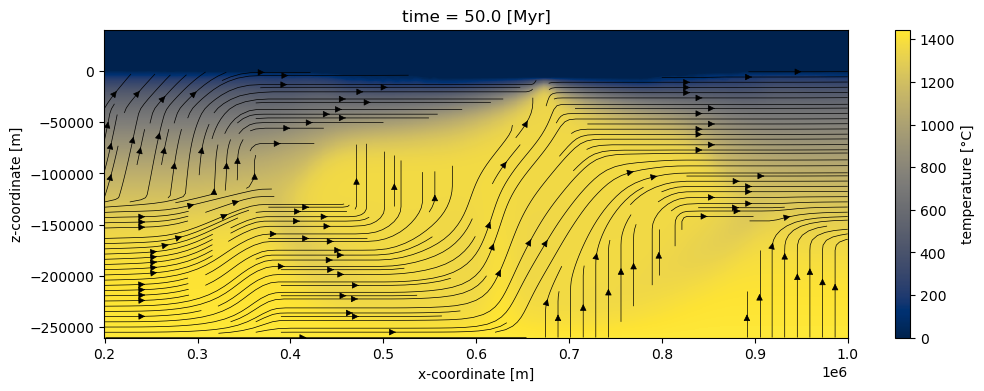

In [74]:
plt.figure(figsize=(12,4))
mesh = cs15_50myr.mesh['original'].ds
mesh['temperature'].plot.pcolormesh(x='x',y='z',cmap='cividis')
mesh.plot.streamplot(x='x',y='z',u='vx',v='vy', broken_streamlines=True, 
                    density=2.0,
                    color='black', linewidth=0.5)

In [75]:
cs15_50myr.surface['topography']

<xarray.DataTree 'topography'>
Group: /surface/topography
    Dimensions:  (x: 40001)
    Coordinates:
      * x        (x) float32 160kB 2e+05 2e+05 2e+05 2.001e+05 ... 1e+06 1e+06 1e+06
        time     float32 4B 50.0
    Data variables:
        surface  (x) float32 160kB dask.array<chunksize=(40001,), meta=np.ndarray>
        z        (x) float32 160kB dask.array<chunksize=(40001,), meta=np.ndarray>